In [26]:
import pandas as pd
print(pd.__version__)
import requests
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"
response = requests.get(url)
open("car_fuel_efficiency.csv", "wb").write(response.content)

df = pd.read_csv("car_fuel_efficiency.csv")
df.head()

2.3.2


,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


The goal of this homework is to create a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg').

Preparing the dataset
Use only the following columns:

'engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg'

EDA

Look at the fuel_efficiency_mpg variable. Does it have a long tail?
- **No**

In [5]:
df_subset = df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]

<Figure size 1500x1000 with 0 Axes>

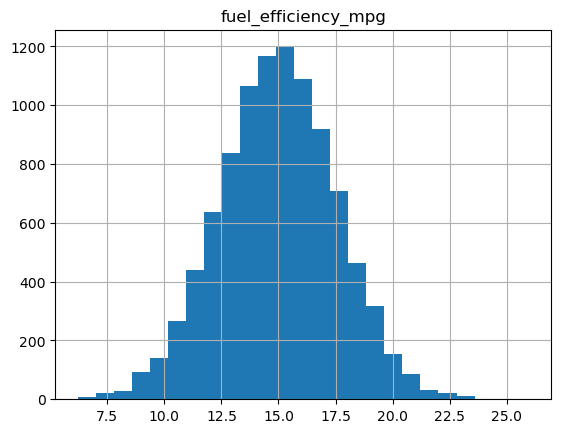

In [6]:
plt.figure(figsize=(15, 10))
df_subset[['fuel_efficiency_mpg']].hist(bins=25)
plt.show()

Question 1
There's one column with missing values. What is it?

- 'engine_displacement'
- 'horsepower'
- 'vehicle_weight'
- 'model_year'

Answer:
- horsepower

In [24]:
a = df_subset.isnull().sum()
print(a[a>0])


horsepower    708
dtype: int64


Question 2
What's the median (50% percentile) for variable 'horsepower'?

49
99
**149**
199

In [25]:
df_subset['horsepower'].median()

149.0

Prepare and split the dataset
- Shuffle the dataset (the filtered one you created above), use seed 42.
- Split your data in train/val/test sets, with 60%/20%/20% distribution.
Use the same code as in the lectures

Question 3
We need to deal with missing values for the column from Q1.
We have two options: 
- fill it with 0 
- with the mean of this variable.

Try both options. For each, train a linear regression model without regularization using the code from the lessons.
For computing the mean, use the training only!
Use the validation dataset to evaluate the models and compare the RMSE of each option.
Round the RMSE scores to 2 decimal digits using round(score, 2)
Which option gives better RMSE?

In [34]:
n = len(df_subset)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

df_shuffled = df_subset.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [38]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]


def prepare_X(df, fillna_value):
    df = df.fillna(fillna_value)
    X = df.values
    return X


def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)


In [40]:
mean = df_train.horsepower.mean()
X_train = prepare_X(df_train, fillna_value=mean)
w_0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, fillna_value=mean)
y_pred = w_0 + X_val.dot(w)

print("mean value fill: ", rmse(y_val, y_pred))

X_train = prepare_X(df_train, fillna_value=0)
w_0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, fillna_value=0)
y_pred = w_0 + X_val.dot(w)

print("zero value fill: ", rmse(y_val, y_pred))


mean value fill:  0.4635965042329052
zero value fill:  0.5173782638837691


Question 4
Now let's train a regularized linear regression.
For this question, fill the NAs with 0.
Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
Use RMSE to evaluate the model on the validation dataset.
Round the RMSE scores to 2 decimal digits.
Which r gives the best RMSE?
If there are multiple options, select the smallest r.

Options:

0
0.01
1
10
100

In [ ]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [51]:
X_train = prepare_X(df_train, fillna_value=0)
X_val = prepare_X(df_val, fillna_value=0)

for r in [0, 0.001, 0.01, 0.1, 1, 10]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_val.dot(w)
    rmse_val = rmse(y_val, y_pred)
    print('%06s %0.2f' % (r, rmse_val))


     0 0.52
 0.001 0.52
  0.01 0.52
   0.1 0.52
     1 0.52
    10 0.52


Question 5
We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
For each seed, do the train/validation/test split with 60%/20%/20% distribution.
Fill the missing values with 0 and train a model without regularization.
For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
Round the result to 3 decimal digits (round(std, 3))

**Answer: 0.006**

In [57]:
def split_dataset_with_seed(df, seed=42):
    n = len(df)

    n_val = int(0.2 * n)
    n_test = int(0.2 * n)
    n_train = n - (n_val + n_test)

    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_shuffled = df.iloc[idx]

    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_test = df_shuffled.iloc[n_train+n_val:].copy()

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    return df_train, y_train, df_val, y_val, df_test, y_test

In [59]:
df_evaluation_std = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, y_train, df_val, y_val, df_test, y_test = split_dataset_with_seed(df_subset, seed=seed)
    X_train = prepare_X(df_train, fillna_value=0)
    X_val = prepare_X(df_val, fillna_value=0)
    w_0, w = train_linear_regression(X_train, y_train)
    y_pred = w_0 + X_val.dot(w)
    rmse_val = rmse(y_val, y_pred)
    df_evaluation_std.append((seed, rmse_val))
    print('%06s %0.3f' % (seed, rmse_val))

df_evaluation_std = pd.DataFrame(df_evaluation_std, columns=['seed', 'rmse'])
std_scores = df_evaluation_std.rmse.std()
print("std of scores with different seed: ", round(std_scores,3))

     0 0.521
     1 0.521
     2 0.523
     3 0.516
     4 0.511
     5 0.528
     6 0.531
     7 0.509
     8 0.515
     9 0.513
std of scores with different seed:  0.007


Question 6
Split the dataset like previously, use seed 9.
Combine train and validation datasets.
Fill the missing values with 0 and train a model with r=0.001.
What's the RMSE on the test dataset?
Options:

0.15
**0.515**
5.15
51.5


In [63]:
df_train, y_train, df_val, y_val, df_test, y_test = split_dataset_with_seed(df_subset, seed=9)
df_train_val = pd.concat([df_train, df_val])
y_train_val = np.concatenate([y_train, y_val])
X_train_val = prepare_X(df_train_val, fillna_value=0)
X_test = prepare_X(df_test, fillna_value=0)
r = 0.001
w_0, w = train_linear_regression_reg(X_train_val, y_train_val, r=r)
y_pred = w_0 + X_test.dot(w)
rmse_test = rmse(y_test, y_pred)
print("rmse test: ", rmse_test)


rmse test:  0.5156261299162689
